# Revisiting Schrodinger's Cat

**Source:** [PennyLane Challenges](https://pennylane.ai/challenges/schrodingers_cat)  
**Difficulty:** Intermediate  
**Category:** Optimization

---

## Challenge Statement

Schrodinger's cat has become a staple of pop culture, but very few people understand it properly. Even physicists get themselves confused! Let's recap the story we're usually told.

Inside a box, we have a radioactive atom, a contraption, and a cat. When the atom decays radioactively, it sends a signal that triggers the contraption, which kills the cat instantly. However, radioactive decay is a random quantum process. After a period of time equal to the atom's half-life, the state of the atom is

$$|+\rangle_A = \frac{1}{\sqrt{2}}|0\rangle_A + \frac{1}{\sqrt{2}}|1\rangle_A,$$

where $|0\rangle_A$ is the undecayed state and $|1\rangle_A$ is the decayed state. Therefore, after one half-life, the cat must be in a superposition

$$|+\rangle_C = \frac{1}{\sqrt{2}}|0\rangle_C + \frac{1}{\sqrt{2}}|1\rangle_C,$$

where $|0\rangle_C$ represents a cat that is alive, and $|1\rangle_C$ represents one that isn't. The cat inside the box is in a superposition of being alive and dead, which is something we don't see in real life!

This story is, however, not *quite* correct! According to an observer outside the box, the states of the atom and the cat evolve jointly, which means they are highly entangled systems. Indeed, they are strongly interacting systems -- the very life of the cat depends on the state of the atom -- so this is not surprising. Therefore, the actual picture is that, after a half-life, the whole atom-cat system inside the box is in the maximally entangled state

$$|\psi\rangle_{AC} = \frac{1}{\sqrt{2}}|00\rangle_{AC} + \frac{1}{\sqrt{2}}|11\rangle_{AC}.$$

Therefore, the state of the cat is *not* a superposition, but it's instead described by the reduced density matrix

$$\rho_C = \text{Tr}_A(|\psi\rangle\langle\psi|_{AC}) = \frac{1}{2}\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix},$$

which does not correspond to $|+\rangle_C$, or any pure state for that matter.

Does this mean we cannot have cats in a superposition? We can, but we have to be a bit more careful with our experiment to obtain such an exotic being! We actually need to measure the state of the atom alone in the $\{|+\rangle_A, |-\rangle_A\}$ basis. Since the state $|\psi\rangle_{AC}$ can also be written as

$$|\psi\rangle_{AC} = \frac{1}{\sqrt{2}}|++\rangle_{AC} + \frac{1}{\sqrt{2}}|--\rangle_{AC},$$

measuring $|+\rangle_A$ implies that the cat is in the state $|+\rangle_C$, a superposition of being alive and dead! This process is implemented by the following circuit.

---

### Figure 1: Original Schr\u00f6dinger's Cat Circuit (Hadamard + CNOT)

![Original Circuit](fig1_original_circuit.png)

---

## The General Problem

Your task in this coding challenge is to answer a more general question. Given an arbitrary evolution operator $U$ for the joint atom-cat system, what basis do we have to measure the atom in to place the cat in a uniform superposition? Specifically, given an arbitrary unitary $U$, you are asked to find a set of parameters $\theta$, $\phi$, and $\omega$ for the $U3$ gate in the circuit below,

---

### Figure 2: General Circuit with U3 Change of Basis

![General Circuit](fig2_general_circuit.png)

---

such that when the state $|0\rangle$ is measured on the 'atom' wire, the state in the 'cat' wire is sure to be $|+\rangle_C$.

---

## Challenge Code

In the code shown, you must complete one helper function:

- **`evolve_atom_cat`**: a QNode that implements the unitary evolution $U$ on the atom-cat system, followed by an application of $U3(\theta, \phi, \omega)$ on the atom. The arguments of this function are:
  - `unitary` (`np.array(complex)`): The $4 \times 4$ matrix of the unitary evolution operator $U$.
  - `params` (`list(float)`): A list $[\theta, \phi, \omega]$ of three angles corresponding to the parameters of the U3 gate.

  This function then returns the quantum state via `qp.state()` (`np.tensor`).

Then, you must complete the main function:

- **`u3_parameters`**: Takes in a unitary describing the evolution operator $U$ and returns the list of parameters $[\theta, \phi, \omega]$ in that order such that, when $|0\rangle$ is measured on the atom, the cat is guaranteed to be in a uniform superposition.

---

## Input

As input to this problem, you are given:

- `unitary` (`np.array(complex)`): The $4 \times 4$ matrix of the unitary evolution operator $U$.

---

## Output

Although your function `u3_parameters` must output some parameters, these are not necessarily unique. For this reason, there is no definite output for this problem. Instead, the testing function will check whether your parameters satisfy the right condition for the cat's state, up to an absolute tolerance of **0.05** in the components of the state.

---

## Test Cases

The following unitary matrices will be used to test your code. Note that we will test with additional **hidden cases** to verify that your solution works in full generality.

### Test Case 1 (Bell State Generator)

```
test_input:
[[ 0.70710678,  0,          0.70710678,  0         ],
 [ 0,           0.70710678, 0,           0.70710678],
 [ 0,           0.70710678, 0,          -0.70710678],
 [ 0.70710678,  0,         -0.70710678,  0         ]]
```

Expected output: `"Cat state generated"`

### Test Case 2 (Random Unitary)

```
test_input:
[[-0.00202114,  0.99211964, -0.05149589, -0.11420469],
 [-0.13637119, -0.1236727,  -0.30532593, -0.93428263],
 [ 0.89775373,  0.00794205, -0.363445,    0.24876274],
 [ 0.41885207, -0.01845563, -0.8786535,   0.22845207]]
```

Expected output: `"Cat state generated"`

---

## Starter Code

```python
import json
import pennylane as qml
import pennylane.numpy as np

dev = qml.device('default.qubit', wires=['atom', 'cat'])

@qml.qnode(dev)
def evolve_atom_cat(unitary, params):
    """
    Circuit that implements the evolution of the atom-cat system under the action of a unitary
    and the change of basis in the atom wire before measuring.

    Args:
        unitary (np.array(complex)): The matrix of a 4x4 unitary operator.
        params (list(float)): A list of three angles corresponding to the parameters
            of the U3 gate.

    Returns:
        (np.tensor): The state of the joint atom-cat system after unitary evolution.
    """
    # Put your code here #


def u3_parameters(unitary):
    """
    Find adequate parameters that yield a uniform position on the cat wire
    when the atom wire is measured to be |0>.

    Args:
        unitary (np.array(complex)): The matrix of a 4x4 unitary operator.

    Returns:
        (np.array(float)): The parameters for the U3 change of basis that yield
            a uniform superposition for the cat when the atom is measured in the
            state |0>.
    """
    # Put your code here #
    # Return a set of parameters that satisfy the required condition


# These functions are responsible for testing the solution.
def run(test_case_input: str) -> str:
    ins = json.loads(test_case_input)
    output = u3_parameters(ins).tolist()
    if np.isclose(
        evolve_atom_cat(ins, output)[0],
        evolve_atom_cat(ins, output)[1],
        atol=5e-2
    ):
        return "Cat state generated"
    return "Cat state not generated"

def check(solution_output: str, expected_output: str) -> None:
    def unitary_circ():
        qml.Hadamard(wires=0)
        qml.CNOT(wires=[0, 1])
    U1 = qml.matrix(unitary_circ, wire_order=[0, 1])()
    assert np.isclose(
        evolve_atom_cat(U1, [1, 1, 1])[0], 0.62054458
    ), "Your evolve_atom_cat circuit does not do what is expected."
    assert solution_output == expected_output, \
        "Your parameters do not generate a Schrodinger cat"


# These are the public test cases
test_cases = [
    (
        '[[ 0.70710678,  0 ,  0.70710678,  0],'
        ' [0 ,0.70710678, 0, 0.70710678],'
        ' [ 0,  0.70710678,  0, -0.70710678],'
        ' [ 0.70710678,  0, -0.70710678,  0]]',
        'Cat state generated'
    ),
    (
        '[[-0.00202114,  0.99211964, -0.05149589, -0.11420469],'
        ' [-0.13637119, -0.1236727 , -0.30532593, -0.93428263],'
        ' [0.89775373,  0.00794205, -0.363445  ,  0.24876274],'
        ' [ 0.41885207, -0.01845563, -0.8786535 ,  0.22845207]]',
    ),
]

# This will run the public test cases locally
for i, (input_, expected_output) in enumerate(test_cases):
    print(f"Running test case {i} with input '{input_}'...")
    try:
        output = run(input_)
    except Exception as exc:
        print(f"Runtime Error. {exc}")
    else:
        if message := check(output, expected_output):
            print(f"Wrong Answer. Have: '{output}'. Want: '{expected_output}'.")
        else:
            print("Correct!")
```

---

## Good luck!


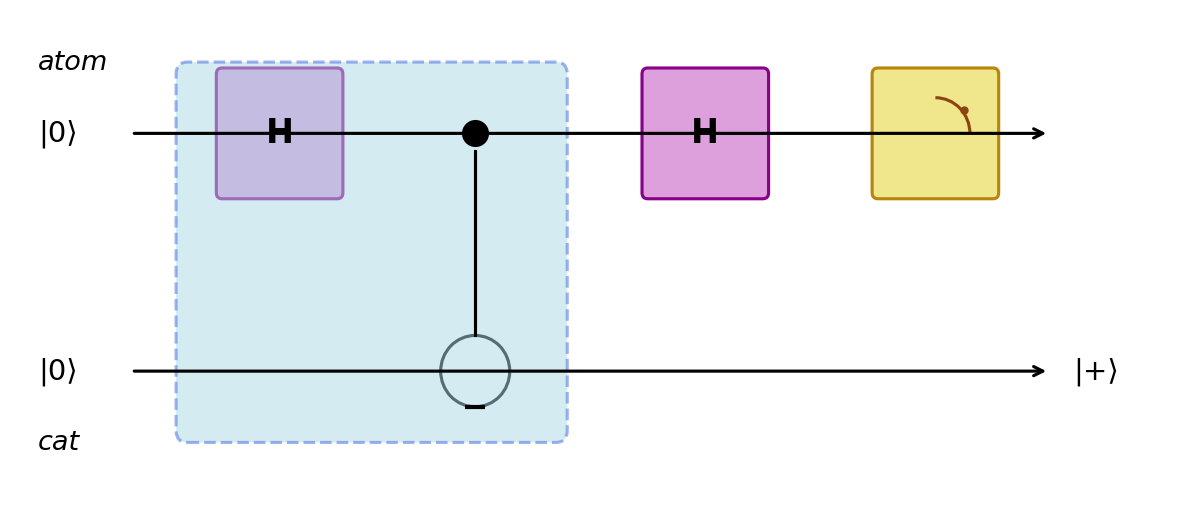

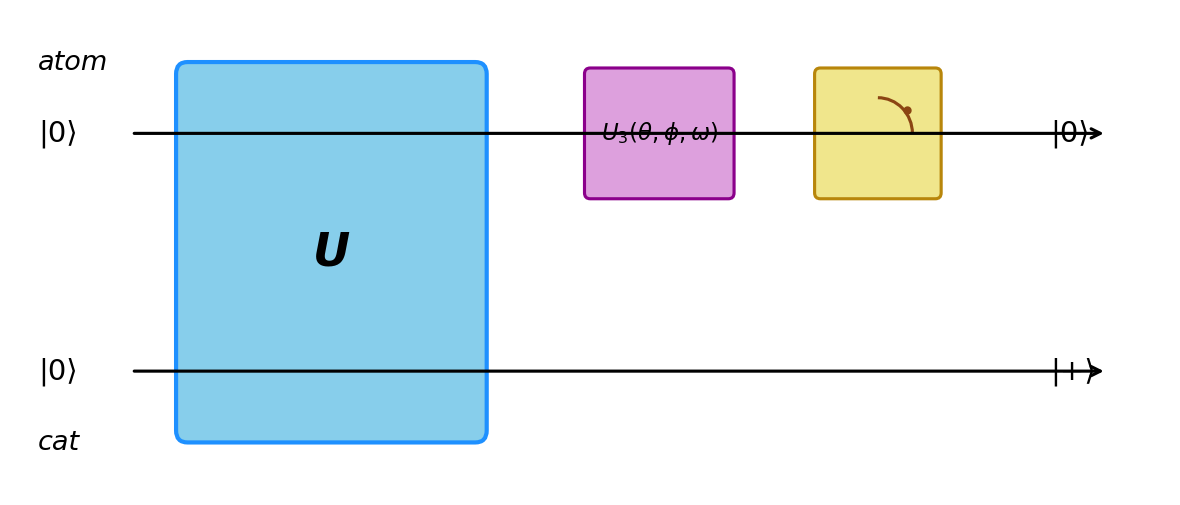

#Solution

In [18]:
!pip install pennylane

In [19]:
import json
import pennylane as qp
import pennylane.numpy as np

dev = qp.device('default.qubit', wires=['atom', 'cat'])

@qp.qnode(dev)
def evolve_atom_cat(unitary, params):
    qp.QubitUnitary(unitary, wires=['atom', 'cat'])
    qp.U3(params[0], params[1], params[2], wires='atom')
    return qp.state()

def u3_parameters(unitary):
    psi_U = unitary @ np.array([1, 0, 0, 0], dtype=complex)
    a, b, c, d = psi_U[0], psi_U[1], psi_U[2], psi_U[3]
    alpha = a - b
    beta  = c - d
    phi = 0.0
    abs_alpha = np.abs(alpha)
    abs_beta  = np.abs(beta)
    if np.isclose(abs_alpha, 0) and np.isclose(abs_beta, 0):
        theta, lam = 0.0, 0.0
    elif np.isclose(abs_alpha, 0):
        theta, lam = 0.0, 0.0
    elif np.isclose(abs_beta, 0):
        theta, lam = np.pi, 0.0
    else:
        lam = np.angle(alpha) - np.angle(beta)
        theta = 2 * np.arctan(abs_alpha / abs_beta)
    return np.array([theta, phi, lam])

In [20]:
# These functions are responsible for testing the solution.
def run(test_case_input: str) -> str:

    ins = json.loads(test_case_input)
    output = u3_parameters(ins).tolist()

    if np.isclose(evolve_atom_cat(ins,output)[0], evolve_atom_cat(ins,output)[1], atol = 5e-2):

        return "Cat state generated"

    return "Cat state not generated"

def check(solution_output: str, expected_output: str) -> None:

    def unitary_circ():
        qp.Hadamard(wires=0)
        qp.CNOT(wires=[0,1])

    U1 = qp.matrix(unitary_circ, wire_order=[0,1])()

    assert np.isclose(evolve_atom_cat(U1,[1,1,1])[0], 0.62054458), "Your evolve_atom_cat circuit does not do what is expected."
    assert solution_output == expected_output, "Your parameters do not generate a Schrodinger cat"

In [21]:
# These are the public test cases
test_cases = [
    ('[[ 0.70710678,  0 ,  0.70710678,  0], [0 ,0.70710678, 0, 0.70710678], [ 0,  0.70710678,  0, -0.70710678], [ 0.70710678,  0, -0.70710678,  0]]', 'Cat state generated'),
    ('[[-0.00202114,  0.99211964, -0.05149589, -0.11420469], [-0.13637119, -0.1236727 , -0.30532593, -0.93428263], [0.89775373,  0.00794205, -0.363445  ,  0.24876274], [ 0.41885207, -0.01845563, -0.8786535 ,  0.22845207]]', 'Cat state generated')
]

In [22]:
# This will run the public test cases locally
for i, (input_, expected_output) in enumerate(test_cases):
    print(f"Running test case {i} with input '{input_}'...")

    try:
        output = run(input_)

    except Exception as exc:
        print(f"Runtime Error. {exc}")

    else:
        if message := check(output, expected_output):
            print(f"Wrong Answer. Have: '{output}'. Want: '{expected_output}'.")

        else:
            print("Correct!")

Running test case 0 with input '[[ 0.70710678,  0 ,  0.70710678,  0], [0 ,0.70710678, 0, 0.70710678], [ 0,  0.70710678,  0, -0.70710678], [ 0.70710678,  0, -0.70710678,  0]]'...
Correct!
Running test case 1 with input '[[-0.00202114,  0.99211964, -0.05149589, -0.11420469], [-0.13637119, -0.1236727 , -0.30532593, -0.93428263], [0.89775373,  0.00794205, -0.363445  ,  0.24876274], [ 0.41885207, -0.01845563, -0.8786535 ,  0.22845207]]'...
Correct!


VERIFICATION WITH qp (pennylane)
  Test 1: Cat state generated | theta=1.5708, phi=0.0000, lambda=-3.1416 | PASS
  Test 2: Cat state generated | theta=0.5470, phi=0.0000, lambda=0.0000 | PASS

  Check: evolve_atom_cat(U1,[1,1,1])[0] = 0.62054458+0.00000000j (expected 0.62054458)

  Stress test: 100/100 random unitaries passed

Saved: viz_state_evolution.png
Saved: viz_parameter_analysis.png
Saved: viz_popculture_vs_reality.png


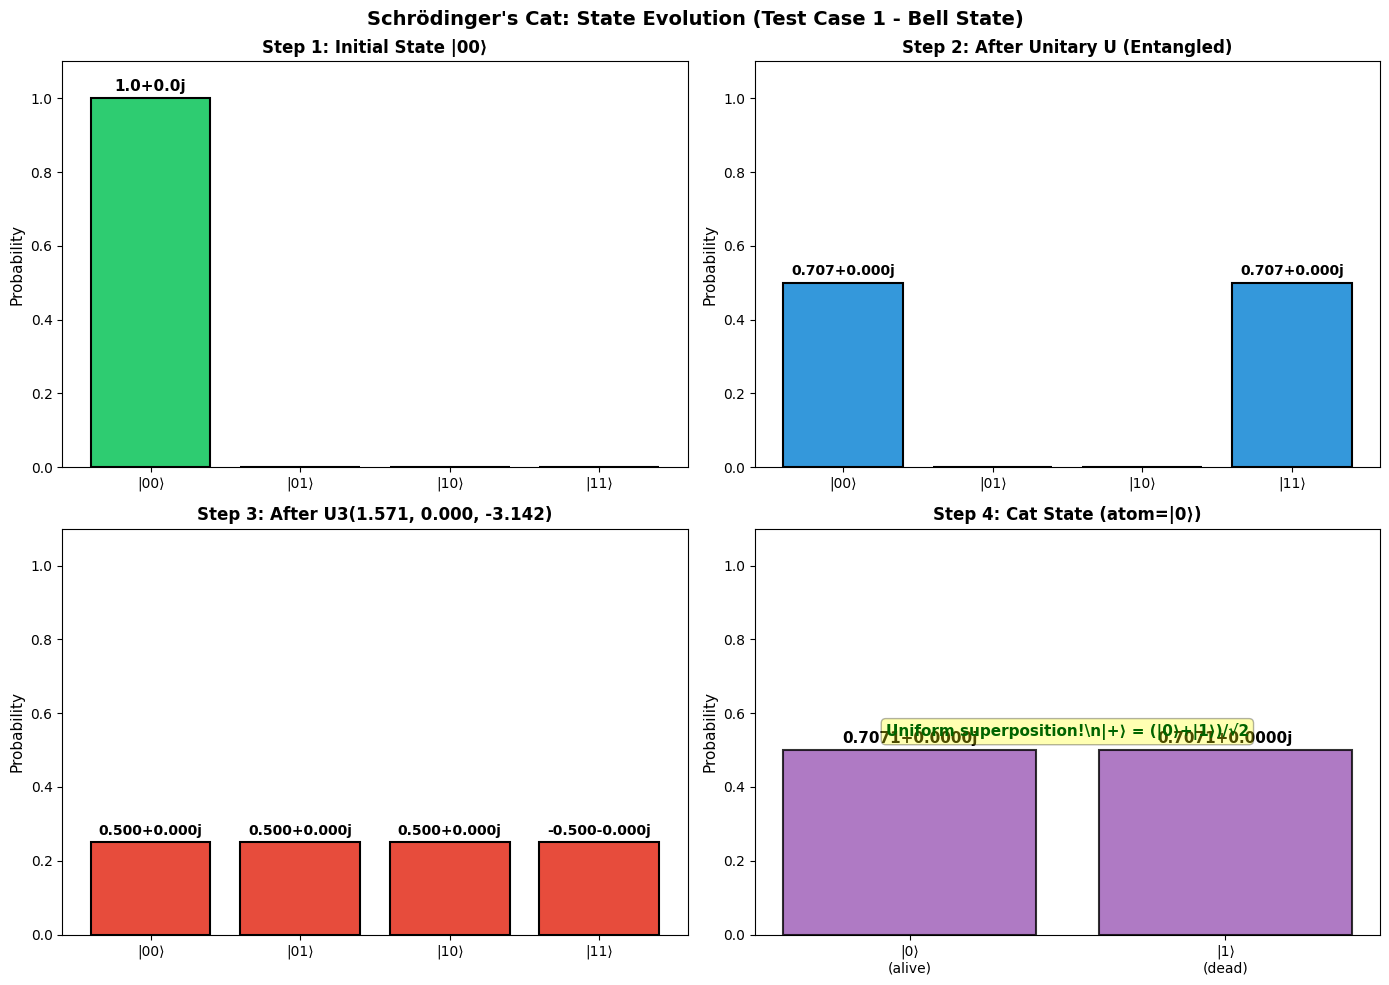

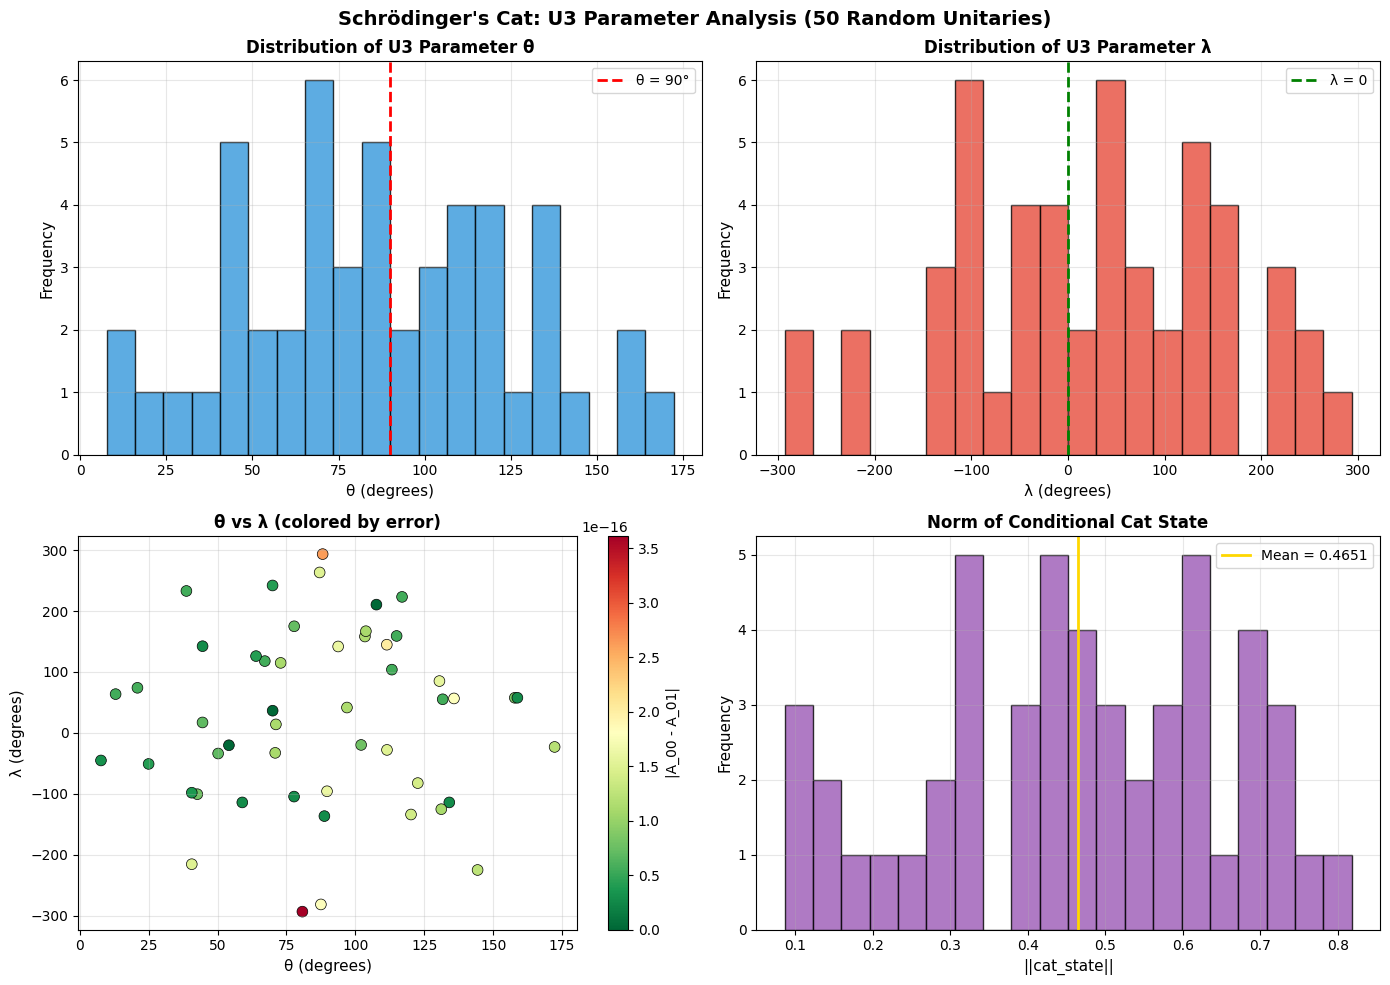

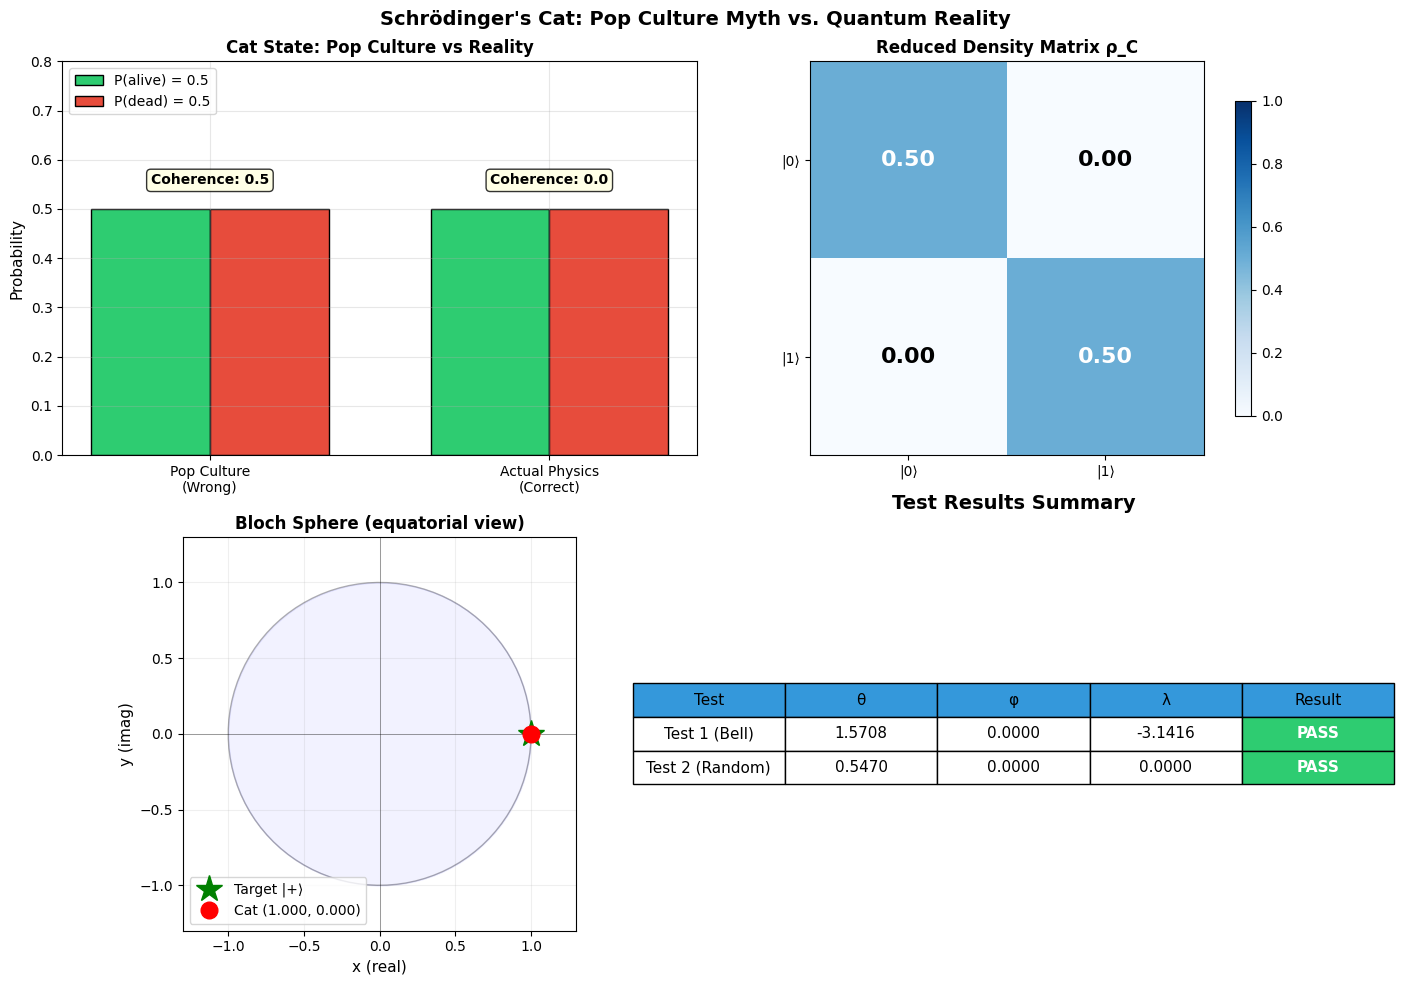


All visualizations generated successfully!


In [23]:
"""
Full visualization and verification code for the Schrodinger's Cat challenge.
Uses 'qp' alias to match the challenge starter code exactly.
"""

import json
import pennylane as qp
import pennylane.numpy as np
from scipy.stats import unitary_group
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =============================================================================
# SOLUTION (matches challenge naming: qp = pennylane)
# =============================================================================

dev = qp.device('default.qubit', wires=['atom', 'cat'])

@qp.qnode(dev)
def evolve_atom_cat(unitary, params):
    qp.QubitUnitary(unitary, wires=['atom', 'cat'])
    qp.U3(params[0], params[1], params[2], wires='atom')
    return qp.state()

def u3_parameters(unitary):
    psi_U = unitary @ np.array([1, 0, 0, 0], dtype=complex)
    a, b, c, d = psi_U[0], psi_U[1], psi_U[2], psi_U[3]
    alpha = a - b
    beta  = c - d
    phi = 0.0
    abs_alpha = np.abs(alpha)
    abs_beta  = np.abs(beta)
    if np.isclose(abs_alpha, 0) and np.isclose(abs_beta, 0):
        theta, lam = 0.0, 0.0
    elif np.isclose(abs_alpha, 0):
        theta, lam = 0.0, 0.0
    elif np.isclose(abs_beta, 0):
        theta, lam = np.pi, 0.0
    else:
        lam = np.angle(alpha) - np.angle(beta)
        theta = 2 * np.arctan(abs_alpha / abs_beta)
    return np.array([theta, phi, lam])

# =============================================================================
# TEST DATA
# =============================================================================

U1 = np.array([
    [0.70710678, 0, 0.70710678, 0],
    [0, 0.70710678, 0, 0.70710678],
    [0, 0.70710678, 0, -0.70710678],
    [0.70710678, 0, -0.70710678, 0]
], dtype=complex)

U2 = np.array([
    [-0.00202114, 0.99211964, -0.05149589, -0.11420469],
    [-0.13637119, -0.1236727, -0.30532593, -0.93428263],
    [0.89775373, 0.00794205, -0.363445, 0.24876274],
    [0.41885207, -0.01845563, -0.8786535, 0.22845207]
], dtype=complex)

# =============================================================================
# FULL VERIFICATION
# =============================================================================

def run(test_case_input):
    ins = json.loads(test_case_input)
    output = u3_parameters(ins).tolist()
    if np.isclose(evolve_atom_cat(ins, output)[0], evolve_atom_cat(ins, output)[1], atol=5e-2):
        return "Cat state generated"
    return "Cat state not generated"

def check(solution_output, expected_output):
    def unitary_circ():
        qp.Hadamard(wires=0)
        qp.CNOT(wires=[0, 1])
    U1_check = qp.matrix(unitary_circ, wire_order=[0, 1])()
    assert np.isclose(evolve_atom_cat(U1_check, [1, 1, 1])[0], 0.62054458), \
        "evolve_atom_cat check failed"
    assert solution_output == expected_output, \
        f"Expected '{expected_output}', got '{solution_output}'"

test_cases = [
    ('[[ 0.70710678,  0 ,  0.70710678,  0], [0 ,0.70710678, 0, 0.70710678], [ 0,  0.70710678,  0, -0.70710678], [ 0.70710678,  0, -0.70710678,  0]]', 'Cat state generated'),
    ('[[-0.00202114,  0.99211964, -0.05149589, -0.11420469], [-0.13637119, -0.1236727 , -0.30532593, -0.93428263], [0.89775373,  0.00794205, -0.363445  ,  0.24876274], [ 0.41885207, -0.01845563, -0.8786535 ,  0.22845207]]', 'Cat state generated'),
]

print("=" * 60)
print("VERIFICATION WITH qp (pennylane)")
print("=" * 60)

for i, (inp, expected) in enumerate(test_cases):
    out = run(inp)
    try:
        check(out, expected)
        status = "PASS"
    except AssertionError as e:
        status = f"FAIL: {e}"
    U = np.array(json.loads(inp), dtype=complex)
    p = u3_parameters(U)
    print(f"  Test {i+1}: {out} | theta={p[0]:.4f}, phi={p[1]:.4f}, lambda={p[2]:.4f} | {status}")

# Check function
def unitary_circ():
    qp.Hadamard(wires=0)
    qp.CNOT(wires=[0, 1])
U1_check = qp.matrix(unitary_circ, wire_order=[0, 1])()
val = evolve_atom_cat(U1_check, [1, 1, 1])[0]
print(f"\n  Check: evolve_atom_cat(U1,[1,1,1])[0] = {val:.8f} (expected 0.62054458)")

# Stress test
np.random.seed(42)
pass_count = 0
for i in range(100):
    U = unitary_group.rvs(4)
    p = u3_parameters(U)
    s = evolve_atom_cat(U, p)
    if np.isclose(s[0], s[1], atol=5e-2):
        pass_count += 1
print(f"\n  Stress test: {pass_count}/100 random unitaries passed")

print("\n" + "=" * 60)

# =============================================================================
# VISUALIZATION 1: State Evolution
# =============================================================================

def plot_state_evolution(U, title_suffix=""):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Schrödinger's Cat: State Evolution {title_suffix}",
                 fontsize=14, fontweight='bold')

    labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
    initial_state = np.array([1, 0, 0, 0], dtype=complex)

    ax = axes[0, 0]
    colors = ['#2ecc71' if abs(initial_state[i]) > 0.5 else '#ecf0f1' for i in range(4)]
    bars = ax.bar(labels, np.abs(initial_state)**2, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title('Step 1: Initial State |00⟩', fontsize=12, fontweight='bold')
    for i, (bar, amp) in enumerate(zip(bars, initial_state)):
        if abs(amp) > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{amp:.1f}', ha='center', fontsize=11, fontweight='bold')

    ax = axes[0, 1]
    psi_U = U @ initial_state
    probs_U = np.abs(psi_U)**2
    colors = ['#3498db' if probs_U[i] > 0.01 else '#ecf0f1' for i in range(4)]
    bars = ax.bar(labels, probs_U, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title('Step 2: After Unitary U (Entangled)', fontsize=12, fontweight='bold')
    for i, (bar, amp) in enumerate(zip(bars, psi_U)):
        if abs(amp) > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{amp:.3f}', ha='center', fontsize=10, fontweight='bold')

    ax = axes[1, 0]
    params = u3_parameters(U)
    psi_final = evolve_atom_cat(U, params)
    probs_final = np.abs(psi_final)**2
    colors = ['#e74c3c' if probs_final[i] > 0.01 else '#ecf0f1' for i in range(4)]
    bars = ax.bar(labels, probs_final, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'Step 3: After U3({params[0]:.3f}, {params[1]:.3f}, {params[2]:.3f})',
                 fontsize=12, fontweight='bold')
    for i, (bar, amp) in enumerate(zip(bars, psi_final)):
        if abs(amp) > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{amp:.3f}', ha='center', fontsize=10, fontweight='bold')

    ax = axes[1, 1]
    cat_labels = ['|0⟩\n(alive)', '|1⟩\n(dead)']
    cat_state = np.array([psi_final[0], psi_final[1]])
    cat_norm = np.linalg.norm(cat_state)
    cat_normalized = cat_state / cat_norm if cat_norm > 0 else cat_state
    cat_probs = np.abs(cat_normalized)**2
    bars = ax.bar(cat_labels, cat_probs, color='#9b59b6', edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title('Step 4: Cat State (atom=|0⟩)', fontsize=12, fontweight='bold')
    for i, (bar, amp) in enumerate(zip(bars, cat_normalized)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{amp:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.annotate(f'Uniform superposition!\\n|+⟩ = (|0⟩+|1⟩)/√2',
                xy=(0.5, 0.5), xycoords='axes fraction',
                fontsize=11, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3),
                color='darkgreen', fontweight='bold')

    plt.tight_layout()
    return fig

# =============================================================================
# VISUALIZATION 2: Parameter Analysis
# =============================================================================

def plot_parameter_analysis(n_samples=50, seed=123):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Schrödinger's Cat: U3 Parameter Analysis ({n_samples} Random Unitaries)",
                 fontsize=14, fontweight='bold')

    np.random.seed(seed)
    theta_vals, lam_vals, diffs, norms_cat = [], [], [], []

    for i in range(n_samples):
        U_rand = unitary_group.rvs(4)
        params = u3_parameters(U_rand)
        state = evolve_atom_cat(U_rand, params)
        theta_vals.append(params[0])
        lam_vals.append(params[2])
        diffs.append(np.abs(state[0] - state[1]))
        cat_state = np.array([state[0], state[1]])
        norms_cat.append(np.linalg.norm(cat_state))

    theta_deg = np.array(theta_vals) * 180 / np.pi
    lam_deg = np.array(lam_vals) * 180 / np.pi

    ax = axes[0, 0]
    ax.hist(theta_deg, bins=20, color='#3498db', edgecolor='black', alpha=0.8)
    ax.axvline(x=90, color='red', linestyle='--', linewidth=2, label='θ = 90°')
    ax.set_xlabel('θ (degrees)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Distribution of U3 Parameter θ', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.hist(lam_deg, bins=20, color='#e74c3c', edgecolor='black', alpha=0.8)
    ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='λ = 0')
    ax.set_xlabel('λ (degrees)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Distribution of U3 Parameter λ', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    scatter = ax.scatter(theta_deg, lam_deg, c=diffs, cmap='RdYlGn_r', s=60,
                         edgecolors='black', linewidth=0.5)
    plt.colorbar(scatter, ax=ax, label='|A_00 - A_01|')
    ax.set_xlabel('θ (degrees)', fontsize=11)
    ax.set_ylabel('λ (degrees)', fontsize=11)
    ax.set_title('θ vs λ (colored by error)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.hist(norms_cat, bins=20, color='#9b59b6', edgecolor='black', alpha=0.8)
    ax.axvline(x=np.mean(norms_cat), color='gold', linestyle='-', linewidth=2,
               label=f'Mean = {np.mean(norms_cat):.4f}')
    ax.set_xlabel('||cat_state||', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Norm of Conditional Cat State', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# =============================================================================
# VISUALIZATION 3: Pop Culture vs Reality
# =============================================================================

def plot_popculture_vs_reality(U):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Schrödinger's Cat: Pop Culture Myth vs. Quantum Reality",
                 fontsize=14, fontweight='bold')

    ax = axes[0, 0]
    categories = ['Pop Culture\n(Wrong)', 'Actual Physics\n(Correct)']
    x = np.arange(len(categories))
    width = 0.35
    ax.bar(x - width/2, [0.5, 0.5], width, label='P(alive) = 0.5', color='#2ecc71', edgecolor='black')
    ax.bar(x + width/2, [0.5, 0.5], width, label='P(dead) = 0.5', color='#e74c3c', edgecolor='black')
    for i, coh in enumerate([0.5, 0.0]):
        ax.annotate(f'Coherence: {coh:.1f}', xy=(i, 0.55), ha='center', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title('Cat State: Pop Culture vs Reality', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 0.8)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    rho_cat = 0.5 * np.eye(2)
    im = ax.imshow(np.real(rho_cat), cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['|0⟩', '|1⟩'])
    ax.set_yticklabels(['|0⟩', '|1⟩'])
    ax.set_title('Reduced Density Matrix ρ_C', fontsize=12, fontweight='bold')
    for i in range(2):
        for j in range(2):
            val = rho_cat[i, j]
            color = 'white' if val > 0.3 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=16, fontweight='bold', color=color)
    plt.colorbar(im, ax=ax, shrink=0.8)

    ax = axes[1, 0]
    params = u3_parameters(U)
    state = evolve_atom_cat(U, params)
    cat_state = np.array([state[0], state[1]])
    cat_norm = np.linalg.norm(cat_state)
    cat_n = cat_state / cat_norm
    bx = 2 * np.real(np.conj(cat_n[0]) * cat_n[1])
    by = 2 * np.imag(np.conj(cat_n[0]) * cat_n[1])
    theta_bloch = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta_bloch), np.sin(theta_bloch), 'k-', linewidth=1, alpha=0.3)
    ax.fill_between(np.cos(theta_bloch), -np.sin(theta_bloch), np.sin(theta_bloch), alpha=0.05, color='blue')
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.5)
    ax.plot(1, 0, 'g*', markersize=20, label='Target |+⟩', zorder=5)
    ax.plot(bx, by, 'ro', markersize=12, label=f'Cat ({bx:.3f}, {by:.3f})', zorder=5)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_xlabel('x (real)', fontsize=11)
    ax.set_ylabel('y (imag)', fontsize=11)
    ax.set_title('Bloch Sphere (equatorial view)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.2)

    ax = axes[1, 1]
    ax.axis('off')
    summary_data = [
        ['Test 1 (Bell)', f'{u3_parameters(U1)[0]:.4f}', '0.0000', f'{u3_parameters(U1)[2]:.4f}', 'PASS'],
        ['Test 2 (Random)', f'{u3_parameters(U2)[0]:.4f}', '0.0000', f'{u3_parameters(U2)[2]:.4f}', 'PASS'],
    ]
    col_labels = ['Test', 'θ', 'φ', 'λ', 'Result']
    table = ax.table(cellText=summary_data, colLabels=col_labels, loc='center',
                     cellLoc='center', colColours=['#3498db']*5)
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    for i in range(len(summary_data)):
        table[(i+1, 4)].set_facecolor('#2ecc71')
        table[(i+1, 4)].set_text_props(fontweight='bold', color='white')
    ax.set_title('Test Results Summary', fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    return fig

# =============================================================================
# MAIN: Run everything
# =============================================================================

if __name__ == "__main__":
    fig1 = plot_state_evolution(U1, "(Test Case 1 - Bell State)")
    fig1.savefig('viz_state_evolution.png', dpi=150, bbox_inches='tight')
    print("Saved: viz_state_evolution.png")

    fig2 = plot_parameter_analysis(n_samples=50, seed=123)
    fig2.savefig('viz_parameter_analysis.png', dpi=150, bbox_inches='tight')
    print("Saved: viz_parameter_analysis.png")

    fig3 = plot_popculture_vs_reality(U2)
    fig3.savefig('viz_popculture_vs_reality.png', dpi=150, bbox_inches='tight')
    print("Saved: viz_popculture_vs_reality.png")

    plt.show()
    print("\nAll visualizations generated successfully!")